# SV3D inference from a RealEstate10K clip

Runs **Stable Video 3D (SV3D_p)** on an input image extracted from a RealEstate10K `.txt` file.

## Important caveats — read before running

**SV3D is trained on single Objaverse objects on plain backgrounds.** Feeding it a real-estate interior scene is a domain mismatch. The model will treat your kitchen/living-room as a single 3D "object" and hallucinate orbital views of it. Outputs will look surreal — that's the model behaving correctly on out-of-distribution input, not a bug.

**SV3D expects spherical orbit poses (elevation, azimuth)**, not the world-to-camera matrices in RealEstate10K. We approximately translate RE10K poses into SV3D's format by treating the input frame's view direction as the orbit center. This is a lossy transformation — the actual RE10K trajectory (which is mostly a forward dolly through a room) cannot be faithfully expressed as a spherical orbit.

**Use this notebook to see what SV3D does on this input**, not as a tool for your trajectory-comparison research. For actual research-grade experiments comparing priors, you want models trained on the same domain (DFoT for RE10K, AC3D, CameraCtrl).

## 1. GPU + Drive setup

In [18]:
import torch, sys, os

print('python:', sys.version.split()[0])
print('torch :', torch.__version__)
print('CUDA  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device:', torch.cuda.get_device_name(0))
    print('VRAM  : %.1f GB' % (torch.cuda.get_device_properties(0).total_memory / 1e9))
else:
    raise RuntimeError('GPU runtime required. Runtime → Change runtime type → T4 GPU.')

python: 3.12.13
torch : 2.10.0+cu128
CUDA  : True
device: NVIDIA A100-SXM4-40GB
VRAM  : 42.4 GB


In [19]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DRIVE_CACHE = '/content/drive/MyDrive/CV Project/sv3d_cache'
os.makedirs(DRIVE_CACHE, exist_ok=True)

# Use Drive for HuggingFace cache so the ~5 GB SV3D weights persist across sessions
os.environ['HF_HOME'] = DRIVE_CACHE
os.environ['HUGGINGFACE_HUB_CACHE'] = DRIVE_CACHE
print('HF cache:', DRIVE_CACHE)

Mounted at /content/drive
HF cache: /content/drive/MyDrive/CV Project/sv3d_cache


## 2. Clone Stability AI's generative-models repo and install dependencies

SV3D ships in `Stability-AI/generative-models`. The official `simple_video_sample.py` script is what we use for inference.

In [3]:
REPO_DIR = '/content/generative-models'

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Stability-AI/generative-models.git {REPO_DIR}
else:
    print('repo already cloned')

%cd {REPO_DIR}

# The official requirements file pins very old versions. We install only what we need
# for SV3D inference, letting pip resolve compatible versions for Colab's torch.
!pip install -q omegaconf einops kornia open-clip-torch
!pip install -q transformers==4.40.2
!pip install -q -e .
!pip install -q yt-dlp opencv-python imageio[ffmpeg]

repo already cloned
/content/generative-models
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sgm (pyproject.toml) ... done


## 3. Download the SV3D_p checkpoint (~5 GB, cached to Drive)

In [20]:
print('Please log in to Hugging Face by running the following command and entering your token:')
!huggingface-cli login

Please log in to Hugging Face by running the following command and entering your token:
⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.

    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    A token is already saved on your machine. Run `hf auth whoami` to get more information or `hf auth logout` if you want to log out.
    Setting a new token will erase the existing one.
    To log in, `huggingface_hub` requires a token generated from https

In [21]:
from huggingface_hub import hf_hub_download

ckpt_dir = os.path.join(REPO_DIR, 'checkpoints')
os.makedirs(ckpt_dir, exist_ok=True)
ckpt_path = os.path.join(ckpt_dir, 'sv3d_p.safetensors')

if not os.path.exists(ckpt_path):
    print('downloading sv3d_p.safetensors (~5 GB) — first time only')
    print('NOTE: you must accept the model license at https://huggingface.co/stabilityai/sv3d')
    print('and have run `huggingface-cli login` in this session if that gate is enabled')
    downloaded = hf_hub_download(
        repo_id='stabilityai/sv3d',
        filename='sv3d_p.safetensors',
        cache_dir=DRIVE_CACHE,
    )
    # Symlink into the repo's expected location
    if not os.path.exists(ckpt_path):
        os.symlink(downloaded, ckpt_path)
    print('checkpoint at:', ckpt_path)
else:
    print('checkpoint already at:', ckpt_path)

checkpoint already at: /content/generative-models/checkpoints/sv3d_p.safetensors
checkpoint already at: /content/generative-models/checkpoints/sv3d_p.safetensors


## 4. Parse the RealEstate10K `.txt` file

Reuses the parsing pattern from your existing notebook — first line is the YouTube URL, subsequent lines are `timestamp fx fy cx cy 0 0` followed by 12 numbers forming the world-to-camera 3×4 extrinsic.

In [22]:
import numpy as np

def parse_re10k_txt(path):
    with open(path) as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]
    url = lines[0]
    frames = []
    for line in lines[1:]:
        vals = list(map(float, line.split()))
        frames.append({
            'timestamp_us': int(vals[0]),
            'fx': vals[1], 'fy': vals[2], 'cx': vals[3], 'cy': vals[4],
            'extrinsic': np.array(vals[7:19]).reshape(3, 4),  # 3x4 world-to-camera
        })
    return url, frames

# Edit this to point at your .txt file
TXT_PATH = '/content/drive/MyDrive/CV Project/dataset/RealEstate10K/test/0a3b5fb184936a83.txt'

if not os.path.exists(TXT_PATH):
    # Fall back to a manually-uploaded file in /content/
    fallback = '/content/0a3b5fb184936a83.txt'
    if os.path.exists(fallback):
        TXT_PATH = fallback
    else:
        raise FileNotFoundError(f'edit TXT_PATH to point at your .txt file')

url, frames = parse_re10k_txt(TXT_PATH)
print(f'YouTube URL : {url}')
print(f'Total frames: {len(frames)}')

YouTube URL : https://www.youtube.com/watch?v=jQRHwqNC_0U
Total frames: 174
YouTube URL : https://www.youtube.com/watch?v=jQRHwqNC_0U
Total frames: 174


## 5. Extract one input frame from YouTube

Same pattern as your existing notebook: yt-dlp gets a streaming URL, OpenCV seeks to a specific timestamp.

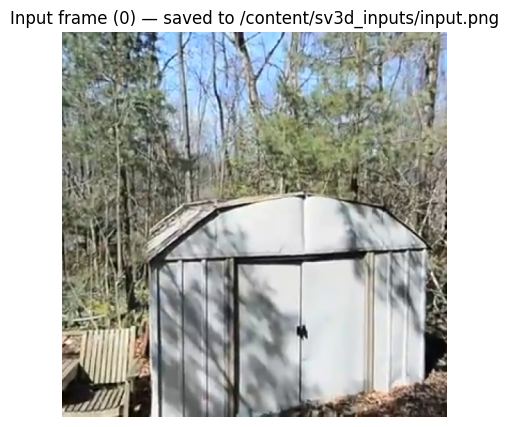

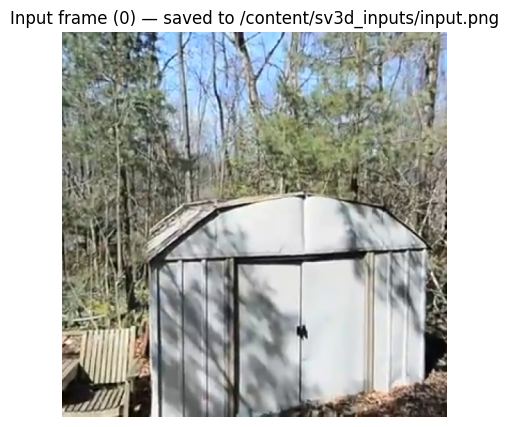

In [23]:
import cv2
import yt_dlp
from PIL import Image
import matplotlib.pyplot as plt

def get_stream_url(youtube_url):
    with yt_dlp.YoutubeDL({'format': 'best[ext=mp4]/best', 'quiet': True}) as ydl:
        return ydl.extract_info(youtube_url, download=False)['url']

def extract_frame_at_us(youtube_url, timestamp_us, out_size=576):
    """Extract one frame, square-center-crop, resize to SV3D's expected resolution (576)."""
    stream = get_stream_url(youtube_url)
    cap = cv2.VideoCapture(stream)
    if not cap.isOpened():
        raise RuntimeError('could not open YouTube stream')
    cap.set(cv2.CAP_PROP_POS_MSEC, timestamp_us / 1000.0)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError(f'could not read frame at {timestamp_us} us')
    # BGR -> RGB
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    # Square center-crop
    h, w = frame.shape[:2]
    s = min(h, w)
    y0, x0 = (h - s) // 2, (w - s) // 2
    frame = frame[y0:y0+s, x0:x0+s]
    frame = cv2.resize(frame, (out_size, out_size), interpolation=cv2.INTER_AREA)
    return frame

# Use the first frame as input
INPUT_FRAME_IDX = 0
input_frame = extract_frame_at_us(url, frames[INPUT_FRAME_IDX]['timestamp_us'])

input_dir = '/content/sv3d_inputs'
os.makedirs(input_dir, exist_ok=True)
input_path = os.path.join(input_dir, 'input.png')
Image.fromarray(input_frame).save(input_path)

plt.figure(figsize=(5, 5))
plt.imshow(input_frame)
plt.title(f'Input frame ({INPUT_FRAME_IDX}) — saved to {input_path}')
plt.axis('off')
plt.show()

## 6. Convert RealEstate10K trajectory to SV3D's spherical orbit format

**This is the lossy step.** SV3D requires 21 (elevation, azimuth) pairs in degrees. RealEstate10K gives world-to-camera matrices for an arbitrary trajectory.

The conversion treats the input frame's gaze direction as the orbit center axis, then projects each subsequent camera pose onto a sphere around that center to get spherical coordinates. For a real RE10K dolly-trajectory this will produce a *near-zero* azimuth sweep — the cameras barely orbit because they're walking in a straight line. We pad/extend to 21 frames as needed.

In [24]:
def re10k_to_spherical_orbit(frames, input_idx, n_views=21, scene_distance=2.0):
    """Approximate conversion from RE10K extrinsics to (elevation, azimuth) degrees.

    Strategy:
      1. Define an orbit center as a point `scene_distance` units in front of
         the input camera along its viewing direction.
      2. For each pose, compute the world-space camera location.
      3. Express that location in spherical coords relative to the orbit center,
         using the input camera's local frame as the reference orientation.
      4. Convert to elevation/azimuth in degrees.
    """
    # Input camera world position and orientation
    E0 = np.eye(4); E0[:3, :4] = frames[input_idx]['extrinsic']
    R0 = E0[:3, :3]
    t0 = E0[:3, 3]
    cam0_pos_world = -R0.T @ t0  # camera center in world frame
    forward_world = R0.T @ np.array([0, 0, 1])  # camera's +Z (view) direction
    orbit_center = cam0_pos_world + scene_distance * forward_world

    # Indices of poses to use, evenly spaced from input_idx to end of clip
    end_idx = min(input_idx + n_views * 2, len(frames))
    pose_indices = np.linspace(input_idx, end_idx - 1, n_views).astype(int)

    elevations, azimuths = [], []
    for i, idx in enumerate(pose_indices):
        Ei = np.eye(4); Ei[:3, :4] = frames[idx]['extrinsic']
        Ri = Ei[:3, :3]; ti = Ei[:3, 3]
        cam_pos = -Ri.T @ ti
        # Vector from orbit center to camera, expressed in input camera's local frame
        v_world = cam_pos - orbit_center
        v_local = R0 @ v_world  # input camera's local axes: x=right, y=down, z=forward
        # Spherical coordinates: elevation from xz-plane, azimuth around y-axis
        r = np.linalg.norm(v_local) + 1e-9
        elev = np.degrees(np.arcsin(-v_local[1] / r))  # negate because y is down
        azim = np.degrees(np.arctan2(v_local[0], v_local[2]))
        # Wrap azimuth to [0, 360)
        azim = (azim + 360) % 360
        elevations.append(float(elev))
        azimuths.append(float(azim))

    # SV3D requires azimuths sorted from 0 to 360. RE10K trajectories will have
    # a tiny azimuth range (near-zero); we sort so SV3D doesn't error out.
    order = np.argsort(azimuths)
    elevations = [elevations[i] for i in order]
    azimuths = [azimuths[i] for i in order]

    return elevations, azimuths

elevations, azimuths = re10k_to_spherical_orbit(frames, INPUT_FRAME_IDX, n_views=21)
print('elevations (degrees):', [f'{e:.1f}' for e in elevations])
print('azimuths (degrees)  :', [f'{a:.1f}' for a in azimuths])
print()
print(f'azimuth range: {min(azimuths):.1f} to {max(azimuths):.1f} degrees')
print(f'elevation range: {min(elevations):.1f} to {max(elevations):.1f} degrees')
print()
if max(azimuths) - min(azimuths) < 30:
    print('WARNING: very narrow azimuth range. The RE10K trajectory is nearly')
    print('straight-line forward motion, which does not map to spherical orbit.')
    print('Consider falling back to a synthetic 360-degree orbit (next cell).')

elevations (degrees): ['0.0', '-0.1', '-0.2', '-0.2', '-0.3', '-1.9', '-0.4', '-1.7', '-0.4', '-1.6', '-0.5', '-1.4', '-0.5', '-0.6', '-0.6', '-1.3', '-0.6', '-0.7', '-1.1', '-0.8', '-1.0']
azimuths (degrees)  : ['180.0', '180.1', '180.2', '180.3', '180.5', '180.5', '180.5', '180.5', '180.6', '180.6', '180.6', '180.6', '180.6', '180.6', '180.6', '180.6', '180.6', '180.6', '180.6', '180.7', '180.7']

azimuth range: 180.0 to 180.7 degrees
elevation range: -1.9 to 0.0 degrees

straight-line forward motion, which does not map to spherical orbit.
Consider falling back to a synthetic 360-degree orbit (next cell).
elevations (degrees): ['0.0', '-0.1', '-0.2', '-0.2', '-0.3', '-1.9', '-0.4', '-1.7', '-0.4', '-1.6', '-0.5', '-1.4', '-0.5', '-0.6', '-0.6', '-1.3', '-0.6', '-0.7', '-1.1', '-0.8', '-1.0']
azimuths (degrees)  : ['180.0', '180.1', '180.2', '180.3', '180.5', '180.5', '180.5', '180.5', '180.6', '180.6', '180.6', '180.6', '180.6', '180.6', '180.6', '180.6', '180.6', '180.6', '180.6', '

## 6b. (Recommended) Use a synthetic 360-degree orbit instead

Because the RE10K-derived trajectory will be a tiny arc that SV3D wasn't designed for, you'll get more visually meaningful (if still domain-mismatched) output by using a standard full-orbit trajectory. The cell below overrides the RE10K-derived elevations/azimuths with a clean 360° orbit at fixed elevation. Skip this cell if you want to use the RE10K-derived trajectory anyway.

In [25]:
# Comment this cell out if you want to use the RE10K-derived trajectory from cell 6
USE_SYNTHETIC_ORBIT = True

if USE_SYNTHETIC_ORBIT:
    elevations = [10.0] * 21                    # constant elevation
    azimuths = list(np.linspace(0, 360, 22)[:-1])  # 21 azimuths in [0, 360)
    print('using synthetic 360-degree orbit at 10 degree elevation')
    print('elevations:', [f'{e:.1f}' for e in elevations])
    print('azimuths  :', [f'{a:.1f}' for a in azimuths])

using synthetic 360-degree orbit at 10 degree elevation
elevations: ['10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0']
azimuths  : ['0.0', '17.1', '34.3', '51.4', '68.6', '85.7', '102.9', '120.0', '137.1', '154.3', '171.4', '188.6', '205.7', '222.9', '240.0', '257.1', '274.3', '291.4', '308.6', '325.7', '342.9']
using synthetic 360-degree orbit at 10 degree elevation
elevations: ['10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0', '10.0']
azimuths  : ['0.0', '17.1', '34.3', '51.4', '68.6', '85.7', '102.9', '120.0', '137.1', '154.3', '171.4', '188.6', '205.7', '222.9', '240.0', '257.1', '274.3', '291.4', '308.6', '325.7', '342.9']


## 7. Run SV3D inference

Calls the official `simple_video_sample.py` script with the SV3D_p variant and our trajectory.

In [26]:
!pip install fire
!pip install pytorch-lightning
!pip install rembg

In [ ]:
!pip install git+https://github.com/openai/CLIP.git

In [27]:
!pip install "rembg[gpu]"

  Using cached onnxruntime_gpu-1.25.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.6 kB)
Using cached onnxruntime_gpu-1.25.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (271.3 MB)


In [29]:
!pip install invisible-watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 80.8 MB/s eta 0:00:00


In [30]:
!pip install xformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.9 MB/s eta 0:00:00


In [31]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [36]:
%cd {REPO_DIR}

elev_str = '[' + ','.join(f'{e:.4f}' for e in elevations) + ']'
azim_str = '[' + ','.join(f'{a:.4f}' for a in azimuths) + ']'
output_dir = '/content/sv3d_outputs'
os.makedirs(output_dir, exist_ok=True)

# encoding_t=1 / decoding_t=1 keeps memory low for T4. Drop these on A100.
# !python scripts/sampling/simple_video_sample.py \
#        --input_path {input_path} \
#        --version sv3d_p \
#        --elevations_deg "{elev_str}" \
#        --azimuths_deg "{azim_str}" \
#        --output_folder {output_dir} \
#        --decoding_t 1 \
#        --encoding_t 1 \
#        --img_size 512
!python scripts/sampling/simple_video_sample.py \
    --input_path {input_path} \
    --version sv3d_p \
    --elevations_deg "{elev_str}" \
    --azimuths_deg "{azim_str}" \
    --output_folder {output_dir}

/content/generative-models
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
Initialized embedder #0: FrozenOpenCLIPImagePredictionEmbedder with 683800065 params. Trainable: False
Initialized embedder #1: VideoPredictionEmbedderWithEncoder with 83653863 params. Trainable: False
Initialized embedder #2: ConcatTimestepEmbedderND w

## 8. Display the output

SV3D writes an mp4 plus per-frame PNGs to `output_folder`.

In [37]:
import glob
from IPython.display import Video, display

mp4s = sorted(glob.glob(f'{output_dir}/**/*.mp4', recursive=True),
              key=os.path.getmtime, reverse=True)
pngs = sorted(glob.glob(f'{output_dir}/**/*.png', recursive=True),
              key=os.path.getmtime, reverse=True)[:21]

print(f'found {len(mp4s)} mp4 file(s) and {len(pngs)} png file(s)')
for p in mp4s[:3]:
    print('  mp4:', p)

if mp4s:
    print('\nshowing newest mp4:')
    display(Video(mp4s[0], embed=True, width=400))

found 2 mp4 file(s) and 0 png file(s)
  mp4: /content/sv3d_outputs/000001.mp4
  mp4: /content/sv3d_outputs/000000.mp4

showing newest mp4:


In [39]:
# Show all 21 generated frames in a grid
if pngs:
    pngs_sorted = sorted(pngs)  # by filename order, which should be frame index
    n = len(pngs_sorted)
    cols = 7
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
    axes = np.array(axes).flatten()
    for i, p in enumerate(pngs_sorted):
        axes[i].imshow(Image.open(p))
        axes[i].set_title(f'{i}', fontsize=8)
        axes[i].axis('off')
    for i in range(len(pngs_sorted), len(axes)):
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

---

## What you should see

If you used the synthetic 360° orbit (cell 6b): SV3D will hallucinate a full orbit around the kitchen interior as if it were a single 3D object. Expect surreal output — walls and counters will warp into something resembling an isolated object on a backdrop. This is SV3D doing what it's trained to do, on input it was never meant to handle.

If you used the RE10K-derived trajectory: the output will be even more degenerate because the azimuth range is ~5°, which is well outside SV3D's training distribution.

**This is not a research-quality result.** It demonstrates what happens when an Objaverse-trained orbit specialist sees indoor-scene input. For your actual trajectory-bias study, stay with DFoT (RE10K-trained, scene-domain) and add CameraCtrl or AC3D as the broader-distribution comparison — those are trained on real scene data and will give you meaningful comparisons.

Try on the objaverse input

In [40]:
## 9. Discover bundled demo images

import glob, os

# The Stability repo ships with sample images in a few places
search_dirs = [
    '/content/generative-models/assets',
    '/content/generative-models/assets/test_image.png',
    '/content/generative-models/scripts/sampling/assets',
]

demo_images = []
for d in search_dirs:
    if os.path.isdir(d):
        demo_images.extend(sorted(glob.glob(f'{d}/*.png')))
        demo_images.extend(sorted(glob.glob(f'{d}/*.jpg')))
    elif os.path.isfile(d):
        demo_images.append(d)

# Also do a recursive scan as a fallback
if not demo_images:
    demo_images = sorted(glob.glob('/content/generative-models/**/*.png',
                                    recursive=True))
    # Filter out checkpoints, generated outputs, watermarks, etc.
    demo_images = [p for p in demo_images
                   if 'checkpoint' not in p.lower()
                   and 'output' not in p.lower()
                   and 'watermark' not in p.lower()]

print(f'found {len(demo_images)} candidate demo image(s):')
for i, p in enumerate(demo_images):
    size_kb = os.path.getsize(p) / 1024
    print(f'  [{i}] {p}  ({size_kb:.0f} KB)')

if not demo_images:
    print('\nno bundled images found. The repo may have changed layout.')
    print('You can drop your own object PNG into /content/ and use that path instead.')

found 5 candidate demo image(s):
  [0] /content/generative-models/assets/001_with_eval.png  (4088 KB)
  [1] /content/generative-models/assets/test_image.png  (482 KB)
  [2] /content/generative-models/assets/turbo_tile.png  (2115 KB)
  [3] /content/generative-models/assets/000.jpg  (711 KB)
  [4] /content/generative-models/assets/test_image.png  (482 KB)


using: /content/generative-models/assets/001_with_eval.png
size: (4216, 1024), mode: RGB


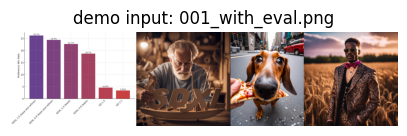

In [41]:
## 10. Pick one and preview it

from PIL import Image
import matplotlib.pyplot as plt

DEMO_INDEX = 0   # change to try a different bundled image

objaverse_input = demo_images[DEMO_INDEX]
print(f'using: {objaverse_input}')

img = Image.open(objaverse_input)
print(f'size: {img.size}, mode: {img.mode}')

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f'demo input: {os.path.basename(objaverse_input)}')
plt.axis('off')
plt.show()

In [42]:
## 11. Run SV3D on the demo image with a clean 360-degree orbit

import numpy as np

%cd /content/generative-models

# Standard SV3D-friendly trajectory: constant elevation, full 360 azimuth sweep
demo_elevations = [10.0] * 21
demo_azimuths = list(np.linspace(0, 360, 22)[:-1])

demo_elev_str = '[' + ','.join(f'{e:.4f}' for e in demo_elevations) + ']'
demo_azim_str = '[' + ','.join(f'{a:.4f}' for a in demo_azimuths) + ']'
demo_output_dir = '/content/sv3d_outputs_objaverse'
os.makedirs(demo_output_dir, exist_ok=True)

!python scripts/sampling/simple_video_sample.py \
    --input_path {objaverse_input} \
    --version sv3d_p \
    --elevations_deg "{demo_elev_str}" \
    --azimuths_deg "{demo_azim_str}" \
    --output_folder {demo_output_dir} \
    --decoding_t 1

/content/generative-models
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
VideoTransformerBlock is using checkpointing
Initialized embedder #0: FrozenOpenCLIPImagePredictionEmbedder with 683800065 params. Trainable: False
Initialized embedder #1: VideoPredictionEmbedderWithEncoder with 83653863 params. Trainable: False
Initialized embedder #2: ConcatTimestepEmbedderND w

In [43]:
## 12. Display the demo output

from IPython.display import Video, display

demo_mp4s = sorted(glob.glob(f'{demo_output_dir}/**/*.mp4', recursive=True),
                   key=os.path.getmtime, reverse=True)
demo_pngs = sorted(glob.glob(f'{demo_output_dir}/**/*.png', recursive=True),
                   key=os.path.getmtime, reverse=True)[:21]

print(f'mp4s: {len(demo_mp4s)}, pngs: {len(demo_pngs)}')

if demo_mp4s:
    print(f'newest mp4: {demo_mp4s[0]}')
    display(Video(demo_mp4s[0], embed=True, width=400))

# Grid of all 21 frames
if demo_pngs:
    pngs_sorted = sorted(demo_pngs)
    n = len(pngs_sorted)
    cols = 7
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
    axes = np.array(axes).flatten()
    for i, p in enumerate(pngs_sorted):
        axes[i].imshow(Image.open(p))
        axes[i].set_title(f'{i}', fontsize=8)
        axes[i].axis('off')
    for i in range(len(pngs_sorted), len(axes)):
        axes[i].axis('off')
    plt.suptitle(f'SV3D on Objaverse-style demo: {os.path.basename(objaverse_input)}',
                 fontsize=10)
    plt.tight_layout()
    plt.show()

mp4s: 1, pngs: 0
newest mp4: /content/sv3d_outputs_objaverse/000000.mp4
